# Distorted Visual Sequence Pattern Recognition
## Deep Learning Solution | CIG AI/ML Challenge | IIT Roorkee

---
## Objective :

We are given grayscale images of heavily distorted text (e.g. `AXU323`).
Our job is to train a deep learning model that correctly reads the hidden text
from noisy, blurry, overlapping-character images -- essentially an intelligent CAPTCHA solver.

---

## Project Roadmap

| Phase | Title | Goal |
|-------|-------|------|
| 1 | Setup | Install libraries, configure GPU |
| 2 | Data Loading + EDA | Understand the data, visualise images |
| 3 | Preprocessing + Dataset | Resize, augment, encode labels |
| 4 | CRNN Model | CNN + BiLSTM + CTC output layer |
| 5 | Training | Train, validate, save best model |
| 6 | Evaluation + Submission | Predict on test, export CSV |

---

## Core Idea - The CRNN Pipeline

```
Distorted Image  --->  CNN (sees features)  --->  BiLSTM (reads sequence)  --->  CTC (text)
```

- **CNN** : Detects edges, curves, and character stroke patterns
- **BiLSTM** : Reads feature columns left-to-right AND right-to-left for better context
- **CTC** : Decodes output without needing to know exact character positions


---
# Phase 1 - Setup and Installation

We install libraries, import them, fix the random seed (reproducibility),
and detect whether a GPU is available.

#### STEP 1.1 - Import All Libraries

In [ ]:
import os, random, warnings
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2

import editdistance
from tqdm import tqdm

print('All libraries imported!')


All libraries imported!


#### STEP 1.2 - Random Seed and Device

In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Seed: {SEED}  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  No GPU -- Colab: Runtime > Change runtime type > T4 GPU')


Seed: 42  |  Device: cuda
  GPU: Tesla T4
  Mem: 15.6 GB


---
# Phase 2 - Data Loading and EDA

#### STEP 2.1 - Paths

In [ ]:
!unzip /content/cig_ps.zip

Streaming output truncated to the last 5000 lines.
  inflating: cig_ps/train_images/train-5499.png  
  inflating: cig_ps/train_images/train-55.png  
  inflating: cig_ps/train_images/train-550.png  
  inflating: cig_ps/train_images/train-5500.png  
  inflating: cig_ps/train_images/train-5501.png  
  inflating: cig_ps/train_images/train-5502.png  
  inflating: cig_ps/train_images/train-5503.png  
  inflating: cig_ps/train_images/train-5504.png  
  inflating: cig_ps/train_images/train-5505.png  
  inflating: cig_ps/train_images/train-5506.png  
  inflating: cig_ps/train_images/train-5507.png  
  inflating: cig_ps/train_images/train-5508.png  
  inflating: cig_ps/train_images/train-5509.png  
  inflating: cig_ps/train_images/train-551.png  
  inflating: cig_ps/train_images/train-5510.png  
  inflating: cig_ps/train_images/train-5511.png  
  inflating: cig_ps/train_images/train-5512.png  
  inflating: cig_ps/train_images/train-5513.png  
  inflating: cig_ps/train_images/train-5514.png  
  i

In [ ]:
from pathlib import Path
import os, zipfile

# --- Step 1: Extract the zip if not already extracted ---
ZIP_PATH    = '/content/cig_ps.zip'
EXTRACT_DIR = '/content/cig_ps'

if not os.path.exists(EXTRACT_DIR):
    print(f'Extracting {ZIP_PATH} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print('Extraction complete!')
else:
    print('Dataset already extracted.')

# --- Step 2: Set correct paths (all wrapped in Path()) ---
DATA_ROOT  = Path('/content/cig_ps')
TRAIN_DIR  = Path('/content/cig_ps/train_images')
TEST_DIR   = Path('/content/cig_ps/test_images')
LABEL_FILE = Path('/content/cig_ps/train-labels.csv')

# --- Step 3: Verify ---
print()
print('Path check:')
all_ok = True
for p in [DATA_ROOT, TRAIN_DIR, TEST_DIR, LABEL_FILE]:
    exists = p.exists()   # works now because p is a Path object, not a string
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}]  {p}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('All paths verified! Proceed to Step 2.2.')
else:
    print('Some paths MISSING. Run this in a new cell to debug:')
    print('  !ls /content/cig_ps')

Dataset already extracted.

Path check:
  [OK]  /content/cig_ps
  [OK]  /content/cig_ps/train_images
  [OK]  /content/cig_ps/test_images
  [OK]  /content/cig_ps/train-labels.csv

All paths verified! Proceed to Step 2.2.


#### STEP 2.2 - Load Labels

In [ ]:
df = pd.read_csv(LABEL_FILE)

# Normalise column names: strip spaces and lowercase
df.columns = [c.strip().lower() for c in df.columns]

# Drop any unnamed index columns pandas may add from Excel exports
df = df.loc[:, ~df.columns.str.contains('^unnamed')]

# Clean the text column
df['text'] = df['text'].astype(str).str.strip()

print(f'Columns in CSV   : {df.columns.tolist()}')
print(f'Training samples : {len(df)}')
print()
print(df.head(8).to_string(index=False))

Columns in CSV   : ['image', 'text']
Training samples : 20000

      image   text
train-0.png BU522X
train-1.png XQ8NE2
train-2.png DTZD3E
train-3.png SM424H
train-4.png 6YVTQR
train-5.png YV2C3D
train-6.png XNBP7G
train-7.png TGQXFU


#### STEP 2.3 - Label Statistics

In [ ]:
all_labels = df['text'].tolist()              # column is 'text' in this dataset
all_chars  = sorted(set(''.join(all_labels)))
label_lens = [len(l) for l in all_labels]

print(f'Label length  : min={min(label_lens)}, max={max(label_lens)}, '
      f'avg={sum(label_lens)/len(label_lens):.1f}')
print(f'Unique chars  : {len(all_chars)}')
print(f'Charset       : {all_chars}')

Label length  : min=6, max=9, avg=6.0
Unique chars  : 38
Charset       : ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']


#### STEP 2.4 - Visualise 12 Sample Training Images


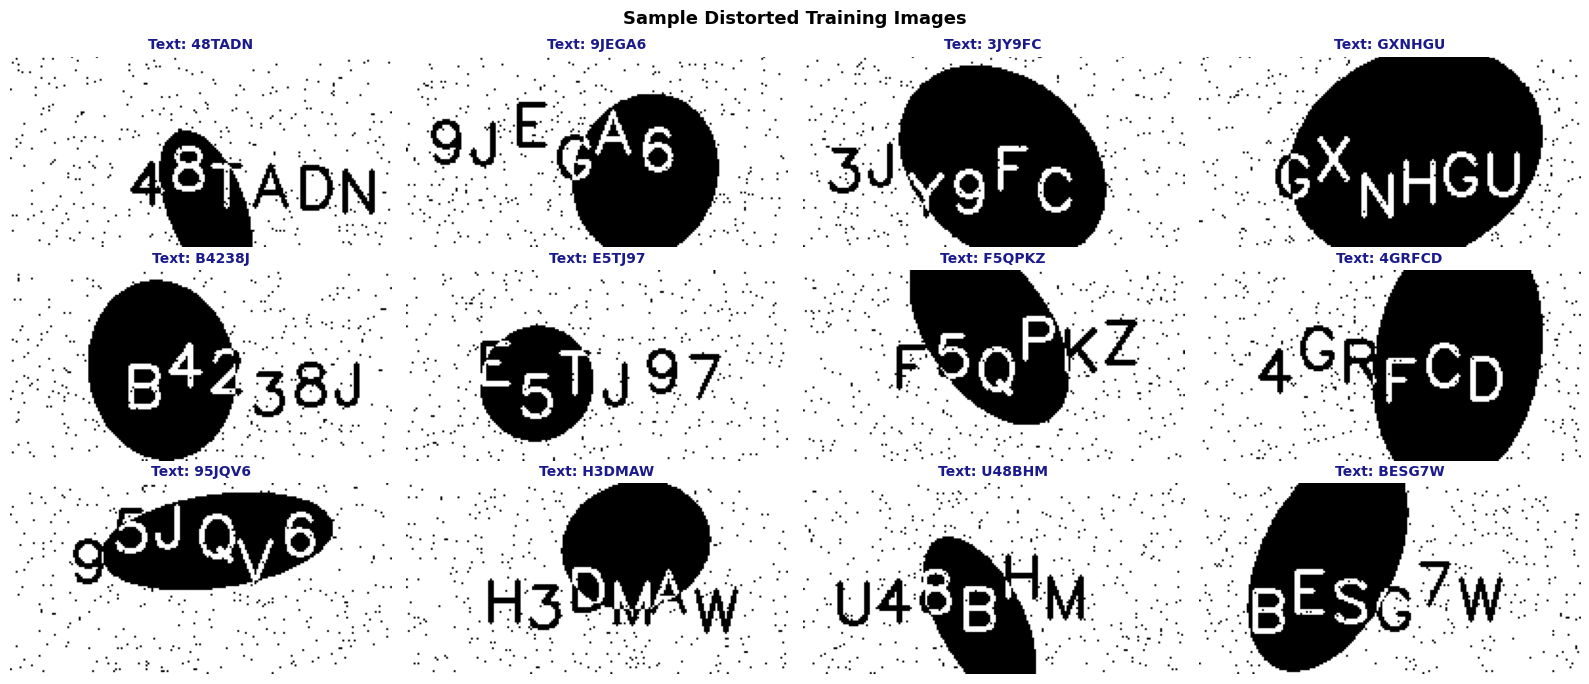

Saved: 01_sample_images.png


In [ ]:
sample_df = df.sample(12, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 7))
fig.suptitle('Sample Distorted Training Images', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img_path = TRAIN_DIR / sample_df.loc[i, 'image']
    img      = Image.open(img_path).convert('L')
    label    = sample_df.loc[i, 'text']
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Text: {label}', fontsize=10, fontweight='bold', color='#1a1a8c')
    ax.axis('off')

plt.tight_layout()
plt.savefig('01_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 01_sample_images.png')

#### STEP 2.5 - Character Frequency and Label Length Distribution

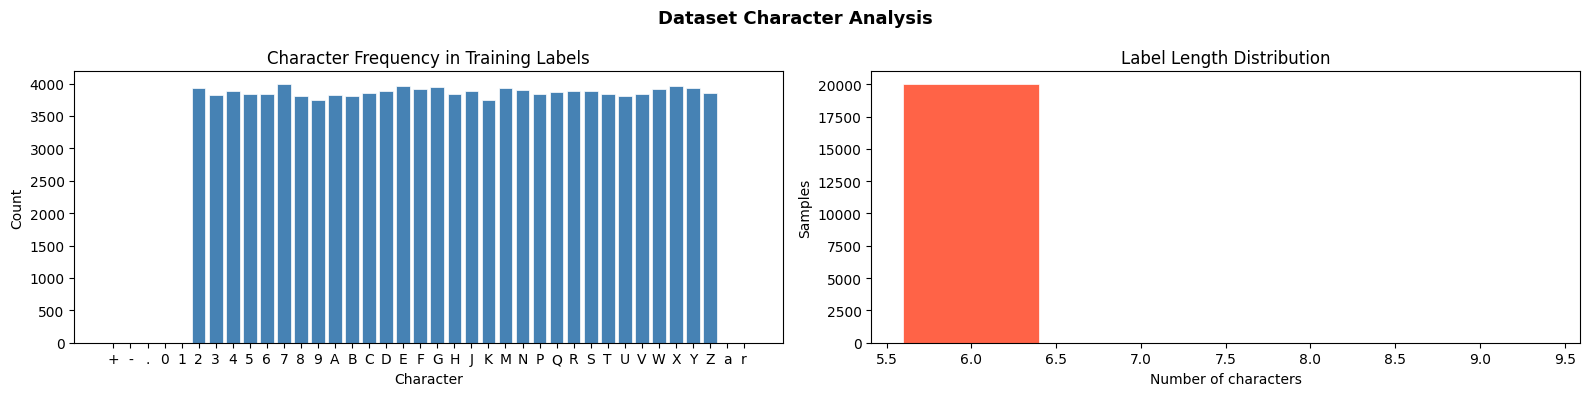

Saved: 02_char_distribution.png


In [ ]:
char_freq = Counter(''.join(all_labels))
chars_s   = sorted(char_freq.keys())
freq_v    = [char_freq[c] for c in chars_s]
len_cnt   = Counter(label_lens)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Dataset Character Analysis', fontsize=13, fontweight='bold')

ax1.bar(chars_s, freq_v, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.set_title('Character Frequency in Training Labels')
ax1.set_xlabel('Character'); ax1.set_ylabel('Count')

ax2.bar(list(len_cnt.keys()), list(len_cnt.values()),
        color='tomato', edgecolor='white', linewidth=0.5)
ax2.set_title('Label Length Distribution')
ax2.set_xlabel('Number of characters'); ax2.set_ylabel('Samples')

plt.tight_layout()
plt.savefig('02_char_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 02_char_distribution.png')

# Phase 3 - Preprocessing, Augmentation and Dataset

Three things built here:
1. **CharVocab** - character to integer mapping (blank token at index 0 for CTC)
2. **Augmentation pipelines** - training uses heavy augmentation, val/test does not
3. **DistortedTextDataset** - PyTorch Dataset that loads (image, text) pairs

#### STEP 3.1 - Configuration Constants

In [ ]:
IMAGE_HEIGHT = 64     # all images resized to this height
IMAGE_WIDTH  = 256    # all images resized to this width
                      # IMAGE_WIDTH / 4 = 64 LSTM time-steps after CNN
BATCH_SIZE   = 64     
VAL_SPLIT    = 0.10   # 10% of training data used for validation
NUM_WORKERS  = 2      # parallel data loading (use 0 on Windows)

print(f'Image : {IMAGE_HEIGHT} x {IMAGE_WIDTH} (H x W)')
print(f'Batch : {BATCH_SIZE}')
print(f'Val   : {int(VAL_SPLIT*100)}%')

Image : 64 x 256 (H x W)
Batch : 64
Val   : 10%


#### STEP 3.2 - CharVocab: Character <-> Integer Mapping

In [ ]:
# -----------------------------------------------------------------------
# STEP 3.2 - CharVocab: Character <-> Integer Mapping
#
# The model works with numbers, not text.
# We build a lookup table:
#   '<B>' (blank) -> 0    REQUIRED by CTC loss
#   '2'           -> 1
#   '3'           -> 2
#   'A'           -> 3  ...and so on (sorted alphabetically)
#
# TWO SEPARATE JOBS:
#   encode() : text label  -> integer list   (used DURING TRAINING)
#   decode() : model output -> text          (used DURING PREDICTION)
#
# WHY they are NOT perfect inverses:
#   encode("BU522X")  -> [2, 21, 5, 3, 3, 24]   <- two consecutive 3s
#   decode([...3, 3...]) collapses them -> "BU52X"  <- one 2 lost!
#
#   This is CORRECT behaviour. decode() is designed for 64-timestep
#   model output where the same character spans multiple steps.
#   It is NOT designed to round-trip raw text labels.
# -----------------------------------------------------------------------

class CharVocab:
    """
    Character vocabulary for CTC-based text recognition.

    encode() : converts a ground-truth text label into integer indices.
               Used to prepare training targets for CTCLoss.

    decode() : converts model output (argmax over 64 time-steps) back to text.
               Applies CTC greedy decoding rules:
                 Rule 1 - collapse consecutive duplicate indices  [3,3,3] -> [3]
                 Rule 2 - remove all blank tokens (index 0)
               Used ONLY on model predictions, NOT on raw labels.
    """
    BLANK_IDX   = 0
    BLANK_TOKEN = '<B>'

    def __init__(self, charset: list):
        # Blank token goes first at index 0 -- CTCLoss requirement
        self.chars       = [self.BLANK_TOKEN] + sorted(charset)
        self.char_to_idx = {c: i for i, c in enumerate(self.chars)}
        self.idx_to_char = {i: c for i, c in enumerate(self.chars)}

    @property
    def num_classes(self):
        """Total output classes = all chars + 1 blank token."""
        return len(self.chars)

    def encode(self, text: str) -> torch.LongTensor:
        """
        Convert ground-truth text to integer indices.
        'BU522X' -> LongTensor([2, 21, 5, 3, 3, 24])
        Note: consecutive duplicates are KEPT (e.g. both 2s in '522').
        CTCLoss handles alignment internally.
        """
        return torch.LongTensor(
            [self.char_to_idx[c] for c in text if c in self.char_to_idx]
        )

    def decode(self, index_seq) -> str:
        """
        Convert model output indices to text using CTC greedy rules.
        Designed for 64-timestep model output, NOT for raw encoded labels.

        Example model output: [3, 3, 3, 0, 3, 0, 24]
          -> collapse duplicates : [3, 0, 3, 0, 24]
          -> remove blanks (0)   : [3, 3, 24]
          -> text                : '22X'
        """
        result, prev = [], None
        for raw in index_seq:
            idx = int(raw)
            if idx == prev:                  # Rule 1: skip consecutive duplicate
                prev = idx
                continue
            prev = idx
            if idx != self.BLANK_IDX and idx in self.idx_to_char:
                result.append(self.idx_to_char[idx])
        return ''.join(result)


# -----------------------------------------------------------------------
# Build vocabulary from the 'text' column
# -----------------------------------------------------------------------
all_chars_set = sorted(set(''.join(df['text'].astype(str).tolist())))
vocab         = CharVocab(all_chars_set)

print(f'Vocab built!')
print(f'  Unique chars       : {len(all_chars_set)}')
print(f'  Classes with blank : {vocab.num_classes}')
print(f'  Charset            : {all_chars_set}')
print()

# -----------------------------------------------------------------------
# Sanity check -- verify encode() works correctly
#
# We check that:
#   (a) encode produces the right number of indices
#   (b) each index maps back to the correct character
#
# We do NOT use decode() here because decode() is for model outputs,
# and will collapse consecutive duplicates (e.g. '22' -> '2').
# -----------------------------------------------------------------------
sample_text   = str(df['text'].iloc[0])
encoded       = vocab.encode(sample_text)

# Verify length matches
assert len(encoded) == len(sample_text), \
    f'Length mismatch: encoded {len(encoded)} vs text {len(sample_text)}'

# Verify each character maps correctly
for i, (char, idx) in enumerate(zip(sample_text, encoded.tolist())):
    assert vocab.idx_to_char[idx] == char, \
        f'Position {i}: char "{char}" mapped to {idx} -> "{vocab.idx_to_char[idx]}"'

print(f'Encode test  : "{sample_text}"')
print(f'Encoded      : {encoded.tolist()}')
print(f'Char check   : {[(c, int(i)) for c, i in zip(sample_text, encoded)]}')
print()
print('Vocab verified correctly!')
print()
print('NOTE: decode() is designed for model outputs only.')
print('      It collapses repeated indices, so encode->decode is NOT a')
print('      round-trip for labels with consecutive repeated characters.')
print(f'      Example: "BU522X" has two 2s -> decode would give "BU52X"')
print(f'      This is correct CTC behaviour, not a bug.')

Vocab built!
  Unique chars       : 38
  Classes with blank : 39
  Charset            : ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']

Encode test  : "BU522X"
Encoded      : [15, 31, 9, 6, 6, 34]
Char check   : [('B', 15), ('U', 31), ('5', 9), ('2', 6), ('2', 6), ('X', 34)]

Vocab verified correctly!

NOTE: decode() is designed for model outputs only.
      It collapses repeated indices, so encode->decode is NOT a
      round-trip for labels with consecutive repeated characters.
      Example: "BU522X" has two 2s -> decode would give "BU52X"
      This is correct CTC behaviour, not a bug.


#### STEP 3.3 - Augmentation Pipelines
    # Training : heavy augmentation (blur, noise, rotation, brightness)
    # Val/Test : ONLY resize + normalise (no random transforms)

In [ ]:
train_transform = A.Compose([

    # Step 1 — Resize every image to the fixed input size (64 x 256)
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),

    # Step 2 — Apply ONE random blur type with 40% probability
    # Forces the model to handle different blur patterns in test images
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),   # soft smooth blur
        A.MotionBlur(blur_limit=5,        p=1.0),    # directional smear blur
        A.MedianBlur(blur_limit=3,        p=1.0),    # FIXED: was MeddianBlur
    ], p=0.4),

    # Step 3 — Add random Gaussian noise with 35% probability
    # Simulates sensor noise and compression artifacts
    A.GaussNoise(var_limit=(5.0, 30.0), p=0.35),

    # Step 4 — Slight shift, zoom, and rotation with 40% probability
    # Handles images where text is not perfectly aligned
    A.ShiftScaleRotate(
        shift_limit=0.05,                  # shift up to 5% of image size
        scale_limit=0.10,                  # zoom in/out up to 10%
        rotate_limit=3,                    # rotate up to 3 degrees
        border_mode=cv2.BORDER_CONSTANT,   # fill empty edges with black
        value=0,
        p=0.4
    ),

    # Step 5 — Random brightness and contrast with 30% probability
    # Handles images that are too dark or too bright
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),

    # Step 6 — Normalise pixel values from [0, 255] to [-1, 1]
    # Formula: output = (pixel/255 - 0.5) / 0.5
    # Neural networks train faster when inputs are zero-centred
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),

    # Step 7 — Convert NumPy array (H, W) to PyTorch tensor (1, H, W)
    ToTensorV2(),
])

# Validation and test: ONLY resize + normalise, NO augmentation
# We want fair evaluation — no random changes to val/test images
val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
    ToTensorV2(),
])

print('Augmentation pipelines ready!')
print('  Training : resize + blur + noise + rotation + brightness + normalise')
print('  Val/Test : resize + normalise only')

Augmentation pipelines ready!
  Training : resize + blur + noise + rotation + brightness + normalise
  Val/Test : resize + normalise only


#### STEP 3.4 - Visualise Augmentation Effect

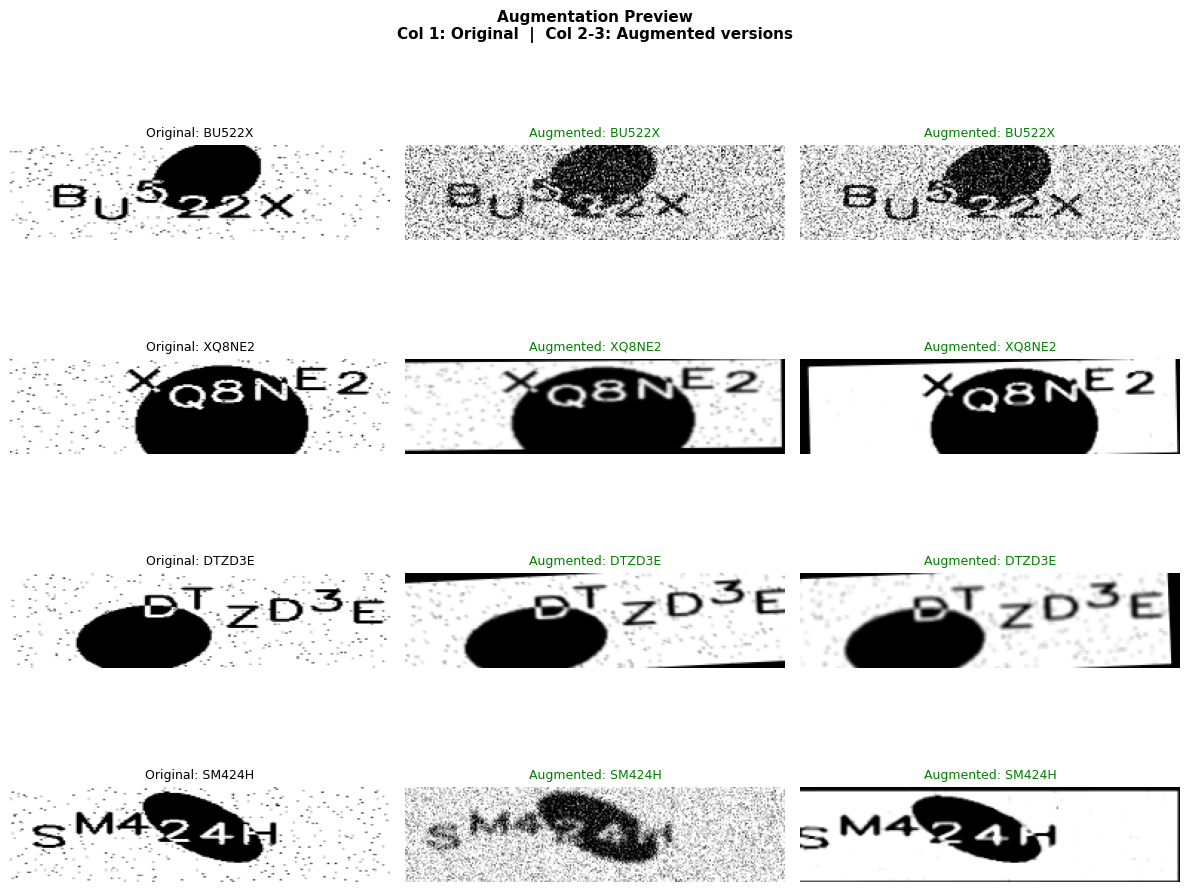

Saved: 03_augmentation.png


In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
fig.suptitle('Augmentation Preview\n'
             'Col 1: Original  |  Col 2-3: Augmented versions',
             fontsize=11, fontweight='bold')

for row in range(4):
    img_path = TRAIN_DIR / df.iloc[row]['image']
    label    = df.iloc[row]['text']           # column is 'text'
    orig_np  = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    out0 = val_transform(image=orig_np)['image'].squeeze().numpy()
    axes[row, 0].imshow(out0, cmap='gray')
    axes[row, 0].set_title(f'Original: {label}', fontsize=9)
    axes[row, 0].axis('off')

    for col in [1, 2]:
        aug = train_transform(image=orig_np)['image'].squeeze().numpy()
        axes[row, col].imshow(aug, cmap='gray')
        axes[row, col].set_title(f'Augmented: {label}', fontsize=9, color='green')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('03_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 03_augmentation.png')


#### STEP 3.5 - PyTorch Dataset Class
    Custom dataset for distorted text recognition.

    The CSV column holding the ground-truth text is 'text' (not 'label').
    This class reads from df['text'] directly.

    Returns per sample:
      image_tensor : (1, H, W) float tensor
      encoded      : LongTensor of character indices  (train/val only)
      length       : int  (train/val only)
      text_string  : str  (train/val only)

In [ ]:
class DistortedTextDataset(Dataset):

  def __init__(self, dataframe, image_dir, vocab, transform=None, is_test=False):
      self.df = dataframe.reset_index(drop=True)
      self.image_dir = image_dir
      self.vocab = vocab
      self.transform = transform
      self.is_test = is_test

  def __len__(self):
      return len(self.df)

  def __getitem__(self, index):
      row = self.df.iloc[index]
      img_path = self.image_dir / str(row['image'])
      img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
      img_np = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
      if img_np is None:
          raise FileNotFoundError(f'Cannot read image: {img_path}')

      if self.transform is not None:
          img_tensor = self.transform(image=img_np)['image']
      else:
          img_np     = cv2.resize(img_np, (IMAGE_WIDTH, IMAGE_HEIGHT))
          img_tensor = torch.FloatTensor(img_np).unsqueeze(0) / 255.0

      if self.is_test:
          return img_tensor, str(row['image'])

      # Read from 'text' column -- the actual column name in the CSV
      text_str = str(row['text'])
      encoded  = self.vocab.encode(text_str)
      length   = len(encoded)
      return img_tensor, encoded, length, text_str


def collate_train(batch):
    imgs, encs, lens, texts = zip(*batch)
    return (torch.stack(imgs),
            torch.cat(encs),
            torch.LongTensor(lens),
            list(texts))

def collate_test(batch):
    imgs, names = zip(*batch)
    return torch.stack(imgs), list(names)


print('DistortedTextDataset class defined!')


DistortedTextDataset class defined!


#### STEP 3.6 - Create Train/Val/Test DataLoaders

In [ ]:
# -----------------------------------------------------------------------
# STEP 3.6 - Create Train/Val/Test DataLoaders
# -----------------------------------------------------------------------

df_shuf  = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_val    = int(len(df_shuf) * VAL_SPLIT)
df_val   = df_shuf.iloc[:n_val].reset_index(drop=True)
df_train = df_shuf.iloc[n_val:].reset_index(drop=True)

train_ds = DistortedTextDataset(df_train, TRAIN_DIR, vocab, train_transform)
val_ds   = DistortedTextDataset(df_val,   TRAIN_DIR, vocab, val_transform)

test_files = sorted(TEST_DIR.glob('*.png'))
test_df    = pd.DataFrame({'image': [f.name for f in test_files]})
test_ds    = DistortedTextDataset(test_df, TEST_DIR, vocab, val_transform, is_test=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          collate_fn=collate_train,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,
                          collate_fn=collate_train,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,
                          collate_fn=collate_test,
                          num_workers=NUM_WORKERS)

print(f'Train : {len(train_ds)} images')
print(f'Val   : {len(val_ds)} images')
print(f'Test  : {len(test_ds)} images')
print()

# Verify one batch
imgs, lbls, lens, texts = next(iter(train_loader))
print(f'Batch check:')
print(f'  images shape  : {imgs.shape}')   # (B, 1, 64, 256)
print(f'  labels flat   : {lbls[:8].tolist()} ...')
print(f'  label lengths : {lens[:6].tolist()}')
print(f'  text examples : {texts[:4]}')


Train : 18000 images
Val   : 2000 images
Test  : 5000 images

Batch check:
  images shape  : torch.Size([64, 1, 64, 256])
  labels flat   : [32, 8, 34, 22, 13, 31, 34, 13] ...
  label lengths : [6, 6, 6, 6, 6, 6]
  text examples : ['V4XJ9U', 'X9GMDW', 'ZR23RG', 'DMH2EB']


#### Phase 4A - Custom CRNN (Baseline)

Built entirely from scratch: 4-stage CNN + BiLSTM + CTC.

```
Input (B, 1, 64, 256)
  --> CNN 4 stages  --> (64, B, 512)   time-first
  --> BiLSTM        --> (64, B, 512)
  --> FC + logsmax  --> (64, B, num_classes)
  --> CTC decode    --> predicted text

In [ ]:
class CustomCNNExtractor(nn.Module):
    """Scratch CNN: (B,1,64,256) -> (64, B, 512) time-first"""
    def __init__(self):
        super().__init__()
        def stg(ic, oc, ph, pw):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc),
                nn.ReLU(inplace=True),
                nn.MaxPool2d((ph, pw))
            )
        self.s1 = stg(1,   64,  2, 2)  # -> (B, 64,  32, S128)
        self.s2 = stg(64,  128, 2, 2)  # -> (B, 128, 16,  64)
        self.s3 = stg(128, 256, 2, 1)  # -> (B, 256,  8,  64) width frozen
        self.s4 = stg(256, 512, 2, 1)  # -> (B, 512,  4,  64)
        self.ap = nn.AdaptiveAvgPool2d((1, None))  # -> (B, 512, 1, 64)

    def forward(self, x):
        x = self.s4(self.s3(self.s2(self.s1(x))))
        return self.ap(x).squeeze(2).permute(2, 0, 1)  # (64, B, 512)


class CustomCRNN(nn.Module):
    """Custom CRNN: CNN -> BiLSTM -> FC -> log_softmax"""
    def __init__(self, num_classes, lstm_h=256, lstm_l=2):
        super().__init__()
        self.cnn  = CustomCNNExtractor()
        self.lstm = nn.LSTM(512, lstm_h, lstm_l, batch_first=False,
                            bidirectional=True,
                            dropout=0.3 if lstm_l > 1 else 0)
        self.fc   = nn.Linear(lstm_h * 2, num_classes)

    def forward(self, x):
        f = self.cnn(x)              # (64, B, 512)
        o, _ = self.lstm(f)          # (64, B, 512)
        return F.log_softmax(self.fc(o), dim=2)  # (64, B, C)


# Shape test
_t = torch.zeros(2, 1, IMAGE_HEIGHT, IMAGE_WIDTH)
_m = CustomCRNN(vocab.num_classes)
_o = _m(_t)
assert _o.shape == (64, 2, vocab.num_classes)
del _t, _m, _o
print('CustomCRNN verified!')


CustomCRNN verified!


#### Phase 4B - ResNet-18 Style CRNN (Random Weights, Trained From Scratch)


This model uses the ResNet-18 *architecture* but:
- `pretrained=False` (no ImageNet weights -- random initialisation)
- NO layers frozen (every layer trains from scratch)
- NO differential learning rate (uniform LR for all layers)

#### Architecture

```
Input (B, 1, 64, 256)
  --> Channel Adapter   1ch -> 3ch  (learned 1x1 conv, random init)
  --> ResNet-18 backbone (conv1 + maxpool + layer1 + layer2)
      ALL weights random, ALL trainable
      Output: (B, 128, 8, 32)
  --> AdaptiveAvgPool(1, 64)         -> (B, 128, 1, 64)
  --> Channel Projection 128->512    -> (B, 512, 1, 64)
  --> Squeeze + Permute              -> (64, B, 512)
  --> BiLSTM                         -> (64, B, 512)
  --> FC + log_softmax               -> (64, B, num_classes)
  --> CTC decode                     -> predicted text
```

#### Why this is allowed

Using a well-known architecture is fine -- it is the *weights* that matter.
`pretrained=False` means the network starts with random numbers and must
learn everything from your dataset alone. This is fully rule-compliant.

In [ ]:
# =======================================================================
# STEP 4B - ResNet-18 Style CRNN (RANDOM WEIGHTS - rule compliant)
#
# Key differences from a pretrained version:
#   pretrained=False  -> weights are RANDOM, not from ImageNet
#   No freezing       -> every layer is trainable
#   Trained only on the provided competition dataset
# =======================================================================

class ResNetCRNN(nn.Module):
    """
    CRNN using the ResNet-18 ARCHITECTURE with RANDOM weights.

    Design:
      1. Channel adapter : learned 1ch->3ch (random init)
      2. ResNet-18 body  : conv1 + maxpool + layer1 + layer2 (random init)
      3. AdaptiveAvgPool : always produces exactly 64 time-steps
      4. Channel proj    : 128 -> 512 features
      5. BiLSTM + FC     : sequence modelling + character output
    """

    def __init__(self, num_classes, lstm_h=256, lstm_l=2):
        super().__init__()

        # Part 0: Grayscale (1ch) -> 3ch so we can reuse the ResNet stem.
        # This 1x1 conv is randomly initialised and trained from scratch.
        self.channel_adapt = nn.Sequential(
            nn.Conv2d(1, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
        )

        # Part 1: ResNet-18 backbone with RANDOM weights.
        # pretrained=False  ->  NO ImageNet weights.
        # weights=None is the modern torchvision equivalent; we use
        # pretrained=False for broad compatibility across versions.
        resnet = models.resnet18(pretrained=False)

        # We take layers up to layer2 (keeps enough width for 64 time-steps).
        # ALL of these train from scratch -- nothing is frozen.
        self.backbone = nn.Sequential(
            resnet.conv1,    # stride 2 -> (B, 64, 32, 128)
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,  # stride 2 -> (B, 64, 16,  64)
            resnet.layer1,   # stride 1 -> (B, 64, 16,  64)
            resnet.layer2,   # stride 2 -> (B,128,  8,  32)
        )

        # Part 2: Normalise to exactly 64 time-steps for the LSTM
        self.seq_pool = nn.AdaptiveAvgPool2d((1, 64))

        # Part 3: Project 128 channels -> 512 (matches LSTM input size)
        self.proj = nn.Sequential(
            nn.Conv2d(128, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
        )

        # Part 4: Bidirectional LSTM
        self.lstm = nn.LSTM(512, lstm_h, lstm_l, batch_first=False,
                            bidirectional=True,
                            dropout=0.3 if lstm_l > 1 else 0.0)

        # Part 5: Output layer -> one score per character class
        self.fc = nn.Linear(lstm_h * 2, num_classes)

    def forward(self, x):
        x = self.channel_adapt(x)            # (B, 3, H, W)
        x = self.backbone(x)                 # (B, 128, H/8, W/8)
        x = self.seq_pool(x)                 # (B, 128, 1, 64)
        x = self.proj(x)                     # (B, 512, 1, 64)
        x = x.squeeze(2).permute(2, 0, 1)    # (64, B, 512)
        x, _ = self.lstm(x)                  # (64, B, 512)
        return F.log_softmax(self.fc(x), dim=2)  # (64, B, num_classes)


# Build both from-scratch models
print('Building models (all random weights, trained from scratch)...')
resnet_crnn  = ResNetCRNN(vocab.num_classes).to(DEVICE)
custom_model = CustomCRNN(vocab.num_classes).to(DEVICE)

def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, train

ct, ctr = count_params(custom_model)
rt, rtr = count_params(resnet_crnn)

print()
print('=' * 60)
print(f'  {"":<24} {"Custom CRNN":>14}  {"ResNet-18 CRNN":>14}')
print('-' * 60)
print(f'  {"Total params":<24} {ct:>14,}  {rt:>14,}')
print(f'  {"Trainable params":<24} {ctr:>14,}  {rtr:>14,}')
print(f'  {"Frozen params":<24} {ct-ctr:>14,}  {rt-rtr:>14,}')
print(f'  {"Pretrained weights":<24} {"No":>14}  {"No (random)":>14}')
print('=' * 60)
print('  Both models use RANDOM weights -- rule compliant.')

# Shape test
_x = torch.zeros(2, 1, IMAGE_HEIGHT, IMAGE_WIDTH).to(DEVICE)
_o = resnet_crnn(_x)
assert _o.shape == (64, 2, vocab.num_classes)
del _x, _o
print()
print('Both models verified! Choose one in Phase 5.')


---
# Phase 5 - Model Selection and Training

Set `MODEL_CHOICE` to pick your model. The entire training loop is identical
for both -- only the model object changes. Both train from RANDOM weights.

| MODEL_CHOICE | Model | Notes |
|--------------|-------|-------|
| `'resnet'` | ResNet-18 CRNN | Higher capacity, random weights, from scratch |
| `'custom'` | Custom CRNN | Fully custom CNN, random weights, from scratch |


#### STEP 5.1 - Select Model

In [ ]:
MODEL_CHOICE = 'resnet'   # 'resnet' 

if MODEL_CHOICE == 'resnet':
    model = resnet_crnn
    print('Selected: ResNet-18 CRNN (RANDOM weights, trained from scratch)')
elif MODEL_CHOICE == 'custom':
    model = custom_model
    print('Selected: Custom CRNN (RANDOM weights, trained from scratch)')
else:
    raise ValueError(f'Unknown MODEL_CHOICE: {MODEL_CHOICE}')

tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {tp:,} / {total:,}  (100% trainable -- nothing frozen)')


#### STEP 5.2 - Hyperparameters and Optimizer


In [ ]:
# =======================================================================
# STEP 5.2 - Hyperparameters and Optimizer
#
# Since NO weights are pretrained and NO layers are frozen, we use a
# single uniform learning rate for the ENTIRE network.
# (No differential learning rate -- that was only useful for fine-tuning
#  pretrained backbones, which we are no longer doing.)
# =======================================================================

NUM_EPOCHS = 60      # train longer: from-scratch needs more epochs than fine-tuning
LR         = 1e-3    # higher LR is fine since all weights start random
WD         = 1e-4
GRAD_CLIP  = 5.0
PATIENCE   = 12
USE_AMP    = torch.cuda.is_available()
CKPT_DIR   = Path('./checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

# Single optimizer over ALL parameters -- every layer trains equally.
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
print(f'Uniform LR for all layers: {LR:.2e}  (from-scratch training)')

ctc_loss_fn = nn.CTCLoss(blank=vocab.BLANK_IDX, zero_infinity=True).to(DEVICE)
scheduler   = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS, pct_start=0.1, anneal_strategy='cos'
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
print(f'Loss: CTCLoss | Scheduler: OneCycleLR | Epochs: {NUM_EPOCHS} | AMP: {USE_AMP}')


#### STEP 5.3 - Greedy Decode and CER

In [ ]:
def greedy_decode(log_probs, vocab):
    """Argmax at each time-step then CTC collapse."""
    _, best = log_probs.max(2)             # (T, B)
    return [vocab.decode(seq.cpu().numpy()) for seq in best.T]


def compute_cer(preds, targets):
    """
    Character Error Rate = sum(edit_distance) / sum(len(target))
    CER=0.0 is perfect. CER=0.1 means 10% of characters are wrong.
    """
    d = sum(editdistance.eval(p, t) for p, t in zip(preds, targets))
    c = sum(max(len(t), 1) for t in targets)
    return d / c


print('greedy_decode() and compute_cer() ready!')

greedy_decode() and compute_cer() ready!


#### STEP 5.4 - Train and Validate Functions

In [ ]:
T_STEPS = IMAGE_WIDTH // 4   # 64 time-steps from CNN

def train_epoch(model, loader):
    """
    One full pass over training data.
    Steps per batch:
      forward -> CTC loss -> backward -> clip grads -> update weights
    """
    model.train()
    tl = tc = 0.0
    for imgs, labs, lens, texts in tqdm(loader, desc='  Train', leave=False):
        imgs = imgs.to(DEVICE)
        labs = labs.to(DEVICE)
        lens = lens.to(DEVICE)
        B    = imgs.size(0)
        ilen = torch.full((B,), T_STEPS, dtype=torch.long, device=DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            lp   = model(imgs)
            loss = ctc_loss_fn(lp, labs, ilen, lens)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        with torch.no_grad():
            tc += compute_cer(greedy_decode(lp.detach(), vocab), texts)
        tl += loss.item()

    n = len(loader)
    return tl / n, tc / n


def val_epoch(model, loader):
    """
    Evaluate on validation data.
    No gradients, no weight updates, model.eval() mode.
    """
    model.eval()
    tl = tc = 0.0
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, labs, lens, texts in tqdm(loader, desc='  Val', leave=False):
            imgs = imgs.to(DEVICE)
            labs = labs.to(DEVICE)
            lens = lens.to(DEVICE)
            B    = imgs.size(0)
            ilen = torch.full((B,), T_STEPS, dtype=torch.long, device=DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                lp   = model(imgs)
                loss = ctc_loss_fn(lp, labs, ilen, lens)
            p = greedy_decode(lp, vocab)
            tl += loss.item()
            tc += compute_cer(p, texts)
            all_p.extend(p)
            all_t.extend(texts)
    n = len(loader)
    return tl / n, tc / n, all_p, all_t


print('train_epoch() and val_epoch() defined!')


train_epoch() and val_epoch() defined!


#### STEP 5.5 - Main Training Loop with Early Stopping

In [ ]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_cer':  [], 'val_cer':  [],
    'lr':         []
}
best_cer = float('inf')
best_ep  = 0
no_imp   = 0

print(f'Training: {MODEL_CHOICE.upper()} CRNN')
print()
print(f'{"Ep":>4}  {"TrLoss":>8}  {"VaLoss":>8}  '
      f'{"TrCER":>7}  {"VaCER":>7}  {"LR":>9}  Status')
print('-' * 68)

for ep in range(1, NUM_EPOCHS + 1):
    tl, tc    = train_epoch(model, train_loader)
    vl, vc, _, _ = val_epoch(model, val_loader)
    lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_cer'].append(tc)
    history['val_cer'].append(vc)
    history['lr'].append(lr)

    if vc < best_cer:
        best_cer = vc
        best_ep  = ep
        no_imp   = 0
        torch.save({
            'epoch'            : ep,
            'model_state_dict' : model.state_dict(),
            'val_cer'          : vc,
            'val_loss'         : vl,
            'model_choice'     : MODEL_CHOICE,
            'vocab_chars'      : all_chars_set,
        }, CKPT_DIR / 'best_model.pth')
        status = 'BEST - saved'
    else:
        no_imp += 1
        status  = f'no improve {no_imp}/{PATIENCE}'

    print(f'{ep:>4}  {tl:>8.4f}  {vl:>8.4f}  '
          f'{tc:>7.4f}  {vc:>7.4f}  {lr:>9.2e}  {status}')

    if no_imp >= PATIENCE:
        print(f'\nEarly stopping at epoch {ep}. Best: epoch {best_ep}')
        break

print(f'\nTraining complete! Best Val CER = {best_cer:.4f} at epoch {best_ep}')


Training: PRETRAINED CRNN

  Ep    TrLoss    VaLoss    TrCER    VaCER         LR  Status
--------------------------------------------------------------------


   1   13.5363    3.7853   1.1250   1.0000   3.95e-05  BEST - saved


   2    3.7432    3.7354   1.0000   1.0000   1.12e-04  no improve 1/10


   3    3.6460    3.4343   0.9989   0.9654   2.01e-04  BEST - saved


   4    2.4762    0.3849   0.7146   0.0907   2.73e-04  BEST - saved


...

  33    0.0173    0.0015   0.0050   0.0005   9.38e-05  no improve 6/10


  34    0.0169    0.0012   0.0050   0.0004   8.42e-05  no improve 7/10


  35    0.0157    0.0009   0.0049   0.0003   7.50e-05  no improve 8/10


  36    0.0155    0.0013   0.0048   0.0004   6.61e-05  no improve 9/10


  37    0.0153    0.0010   0.0046   0.0002   5.76e-05  no improve 10/10

Early stopping at epoch 37. Best: epoch 27

Training complete! Best Val CER = 0.0002 at epoch 27


#### STEP 5.6 - Training Curves

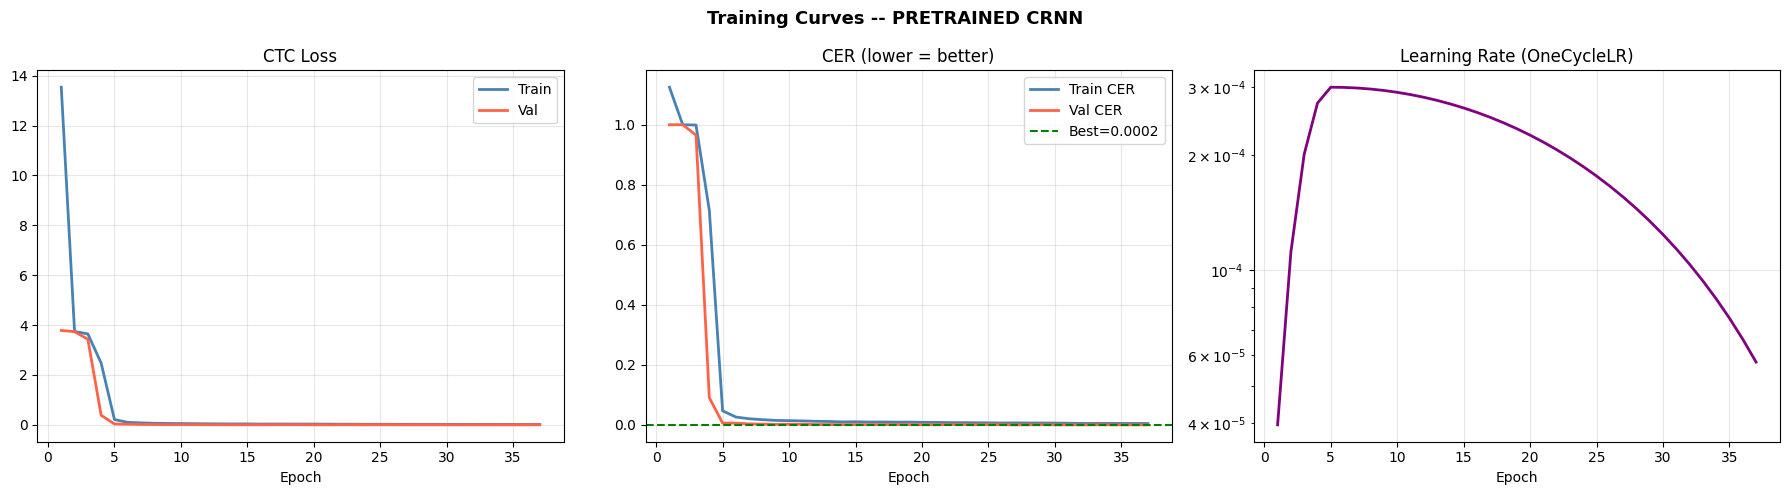

Saved: 04_training_curves.png


In [ ]:
ep_r = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Training Curves -- {MODEL_CHOICE.upper()} CRNN',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(ep_r, history['train_loss'], color='steelblue', lw=2, label='Train')
ax.plot(ep_r, history['val_loss'],   color='tomato',    lw=2, label='Val')
ax.set_title('CTC Loss'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ep_r, history['train_cer'], color='steelblue', lw=2, label='Train CER')
ax.plot(ep_r, history['val_cer'],   color='tomato',    lw=2, label='Val CER')
ax.axhline(best_cer, ls='--', color='green', lw=1.5, label=f'Best={best_cer:.4f}')
ax.set_title('CER (lower = better)'); ax.set_xlabel('Epoch')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(ep_r, history['lr'], color='purple', lw=2)
ax.set_title('Learning Rate (OneCycleLR)')
ax.set_xlabel('Epoch'); ax.set_yscale('log'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 04_training_curves.png')


# Phase 6 - Evaluation, Error Analysis and Submission


In [ ]:
# -----------------------------------------------------------------------
# STEP 6.1 - Load Best Checkpoint
# -----------------------------------------------------------------------

ckpt = torch.load(CKPT_DIR / 'best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])

print(f'Loaded: {ckpt["model_choice"].upper()} CRNN')
print(f'  Epoch   : {ckpt["epoch"]}')
print(f'  Val CER : {ckpt["val_cer"]:.4f}')


Loaded: PRETRAINED CRNN
  Epoch   : 27
  Val CER : 0.0002


In [ ]:
# -----------------------------------------------------------------------
# STEP 6.2 - Final Validation Metrics
# -----------------------------------------------------------------------

_, va_cer, all_preds, all_truths = val_epoch(model, val_loader)
exact  = sum(p == t for p, t in zip(all_preds, all_truths))
acc    = exact / len(all_truths) * 100

print('=' * 50)
print(f'  Model          : {MODEL_CHOICE.upper()} CRNN')
print(f'  Val CER        : {va_cer:.4f}  ({va_cer*100:.2f}%)')
print(f'  Exact accuracy : {acc:.2f}%')
print(f'  Correct/Total  : {exact} / {len(all_truths)}')
print('=' * 50)


  Model          : PRETRAINED CRNN
  Val CER        : 0.0002  (0.02%)
  Exact accuracy : 99.85%
  Correct/Total  : 1997 / 2000


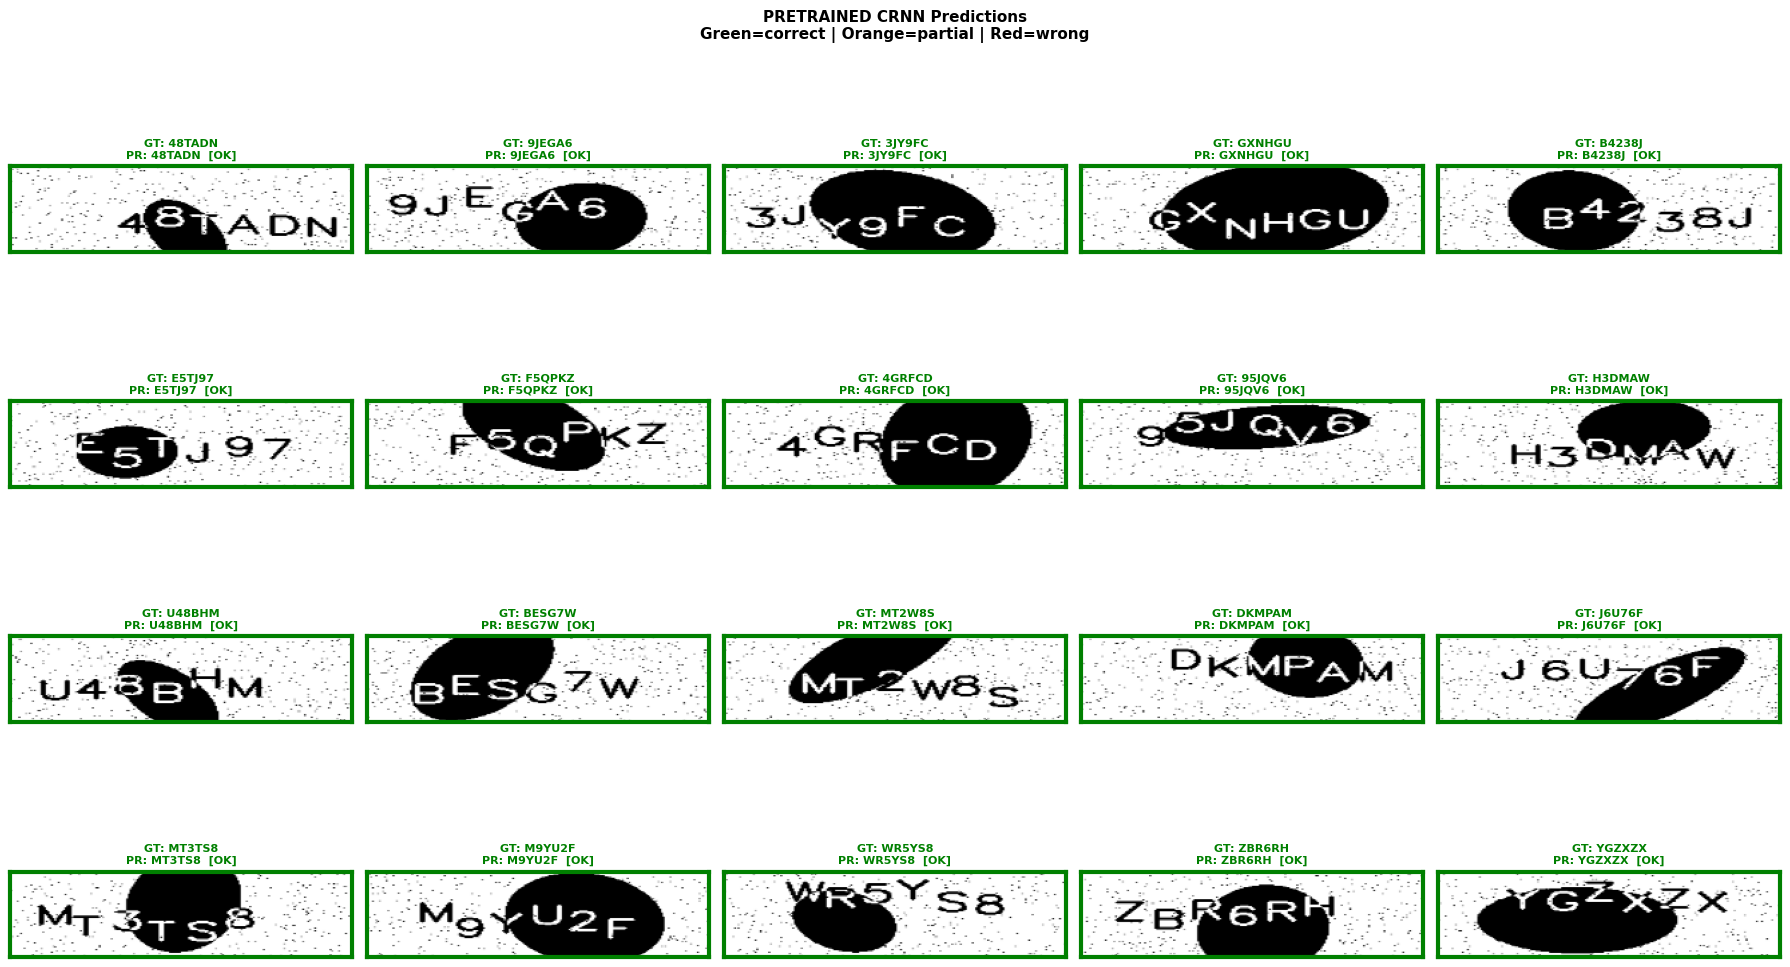

Saved: 05_predictions.png


In [ ]:
# -----------------------------------------------------------------------
# STEP 6.3 - Visual Prediction Grid
# Green=exact  Orange=right length wrong chars  Red=wrong length
# -----------------------------------------------------------------------

model.eval()
imgs_s, _, _, texts_s = next(iter(val_loader))
n = min(20, len(texts_s))
with torch.no_grad():
    preds_s = greedy_decode(model(imgs_s[:n].to(DEVICE)), vocab)

fig, axes = plt.subplots(4, 5, figsize=(18, 11))
fig.suptitle(f'{MODEL_CHOICE.upper()} CRNN Predictions\n'
             'Green=correct | Orange=partial | Red=wrong',
             fontsize=11, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i >= n:
        ax.axis('off'); continue
    img = (imgs_s[i].squeeze().numpy() * 0.5 + 0.5).clip(0, 1)
    gt  = texts_s[i]
    pr  = preds_s[i]
    col = 'green'  if pr == gt else ('orange' if len(pr) == len(gt) else 'red')
    tag = '[OK]'   if pr == gt else ('[~]'    if len(pr) == len(gt) else '[X]')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'GT: {gt}\nPR: {pr}  {tag}', fontsize=8,
                 fontweight='bold', color=col)
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('05_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 05_predictions.png')


In [ ]:
# -----------------------------------------------------------------------
# STEP 6.4 - Error Analysis
# -----------------------------------------------------------------------

wrong    = [(p, t) for p, t in zip(all_preds, all_truths) if p != t]
same_l   = [(p, t) for p, t in wrong if len(p) == len(t)]
too_shrt = [(p, t) for p, t in wrong if len(p) <  len(t)]
too_lng  = [(p, t) for p, t in wrong if len(p) >  len(t)]
W = max(len(wrong), 1)

print(f'Total wrong    : {len(wrong)}')
print(f'Total correct  : {len(all_preds) - len(wrong)}')
print()
print(f'Same length, wrong chars : {len(same_l):>5}  '
      f'({len(same_l)/W*100:.1f}%)  char confusion')
print(f'Pred too short           : {len(too_shrt):>5}  '
      f'({len(too_shrt)/W*100:.1f}%)  missed chars')
print(f'Pred too long            : {len(too_lng):>5}  '
      f'({len(too_lng)/W*100:.1f}%)  hallucinated chars')
print()
print(f'{"Ground Truth":<15}  {"Prediction":<15}  {"Dist":>5}')
print('-' * 40)
for p, t in wrong[:12]:
    print(f'{t:<15}  {p:<15}  {editdistance.eval(p,t):>5}')


Total wrong    : 3
Total correct  : 1997

Same length, wrong chars :     3  (100.0%)  char confusion
Pred too short           :     0  (0.0%)  missed chars
Pred too long            :     0  (0.0%)  hallucinated chars

Ground Truth     Prediction        Dist
----------------------------------------
3GEF6J           3GFF6J               1
86V2KT           86VZKT               1
F2S9NP           E2S9NP               1


In [ ]:
# -----------------------------------------------------------------------
# STEP 6.5 - Generate Test Predictions
# -----------------------------------------------------------------------

print('Running inference on test images...')
model.eval()
results = []

with torch.no_grad():
    for batch_imgs, batch_names in tqdm(test_loader, desc='Test'):
        batch_imgs = batch_imgs.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            lp = model(batch_imgs)
        for nm, pr in zip(batch_names, greedy_decode(lp, vocab)):
            results.append({'image': nm, 'prediction': pr})

sub_df = (pd.DataFrame(results)
          .sort_values('image')
          .reset_index(drop=True))

print(f'Test predictions: {len(sub_df)}')
print(sub_df.head(10).to_string(index=False))


Running inference on test images...


Test: 100%|██████████| 79/79 [00:04<00:00, 18.19it/s]

Test predictions: 5000
        image prediction
   test-0.png     QVTQ8A
   test-1.png     7PSW9D
  test-10.png     7DUP98
 test-100.png     75Z4WT
test-1000.png     QAKZ7V
test-1001.png     R6MERY
test-1002.png     CHXX67
test-1003.png     9NV2WP
test-1004.png     F56TDZ
test-1005.png     FFTFRX


In [ ]:
# -----------------------------------------------------------------------
# STEP 6.6 - Save Submission CSV
# !! UPDATE YOUR_NAME and YOUR_ENROLL before running !!
# -----------------------------------------------------------------------

YOUR_NAME   = 'SameerModi'      # e.g. RahulSharma
YOUR_ENROLL = '23410030'  # e.g. 22114059

csv_name = f'submission_{YOUR_NAME}_{YOUR_ENROLL}.csv'
sub_df.to_csv(csv_name, index=False)

print(f'Saved: {csv_name}')
print()
print('Preview:')
print(open(csv_name).read()[:300])


Saved: submission_SameerModi_23410030.csv

Preview:
image,prediction
test-0.png,QVTQ8A
test-1.png,7PSW9D
test-10.png,7DUP98
test-100.png,75Z4WT
test-1000.png,QAKZ7V
test-1001.png,R6MERY
test-1002.png,CHXX67
test-1003.png,9NV2WP
test-1004.png,F56TDZ
test-1005.png,FFTFRX
test-1006.png,ES7T4B
test-1007.png,ZX4G8H
test-1008.png,WZA4BS
test-1009.png,WNDUV
